<a href="https://colab.research.google.com/github/Shakada26/carisurg-portfolio/blob/main/Week_5_Interim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')

# UPDATE this path to wherever your copy sits in Drive, e.g.:
# '/content/drive/MyDrive/CariSurg/data/yaleemmlc_admissionprediction_triage.csv'
DATA_PATH = '/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Mounted at /content/drive
Loaded dataset: 55,121 rows x 226 columns


## 1. Dataset load & shape
55,121 ED patient records from Dr. De Freitas's Yale-derived dataset (via the Mercer Research Ethics Committee), 226 columns covering demographics, arrival context, 8 triage vitals, and 200 chief-complaint flags.

In [2]:
df.shape


(55121, 226)

## 2. Structure: `.info()` and `.describe()`
`.info()` gives column count, non-null counts, and dtypes in one pass. `.describe()` sanity-checks that vitals fall inside physiologically plausible ranges before we trust anything downstream.

In [3]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Data columns (total 226 columns):
 #    Column                                   Non-Null Count  Dtype  
---   ------                                   --------------  -----  
 0    Unnamed: 0                               55121 non-null  int64  
 1    dep_name                                 55121 non-null  object 
 2    esi                                      55121 non-null  float64
 3    age                                      55121 non-null  float64
 4    gender                                   55121 non-null  object 
 5    ethnicity                                55121 non-null  object 
 6    race                                     55121 non-null  object 
 7    lang                                     55121 non-null  object 
 8    religion                                 55121 non-null  object 
 9    maritalstatus                            55121 non-null  object 
 10   employstatus                    

In [4]:
non_cc_cols = [c for c in df.columns if not c.startswith('cc_')]
vital_cols = ['age', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
              'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'triage_glucose']
df[vital_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,55121.0,55.315470,19.544287,18.0,40.0,55.0,70.0,107.0
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0
triage_vital_rr,55121.0,17.842073,2.066015,8.0,16.0,18.0,18.0,66.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0
triage_glucose,55121.0,130.086138,73.664073,16.0,93.0,107.0,134.0,1066.0


**Note:** vitals fall within physiologically plausible ranges (e.g. HR 32–221, O2 sat 62–99%, temp 91.5–106°F) with no zero/sentinel placeholders standing in for "not taken." That's a good early feasibility signal.

## 3. Dtype audit
Checking every non-chief-complaint column against the dtype its clinical meaning implies — a field coded 0/1/2 shouldn't be treated as continuous just because pandas read it as `float64`.

In [5]:
dtype_audit = pd.DataFrame({
    'dtype': df[non_cc_cols].dtypes.astype(str),
    'n_unique': df[non_cc_cols].nunique(),
    'sample_values': [df[c].dropna().unique()[:3].tolist() for c in non_cc_cols]
})
dtype_audit

,dtype,n_unique,sample_values
Unnamed: 0,int64,55121,"[7, 17, 40]"
dep_name,object,3,"[A, B, C]"
esi,float64,5,"[4.0, 2.0, 3.0]"
age,float64,88,"[87.0, 53.0, 49.0]"
gender,object,2,"[Female, Male]"
ethnicity,object,4,"[Hispanic or Latino, Non-Hispanic, Unknown]"
race,object,8,"[Other, White or Caucasian, Black or African A..."
lang,object,2,"[Other, English]"
religion,object,12,"[Pentecostal, Catholic, Protestant]"
maritalstatus,object,10,"[Widowed, Significant Other, Married]"


In [7]:
suspect = []
for c in non_cc_cols:
    if df[c].dtype == 'float64' and df[c].dropna().apply(float.is_integer).all() and df[c].nunique() <= 5:
        suspect.append(c)
print("Columns stored as float64 that are actually low-cardinality / categorical-coded:")
print(suspect)

Columns stored as float64 that are actually low-cardinality / categorical-coded:
['esi', 'triage_vital_o2_device']


**Note:** no vitals or demographics are mis-typed as text. The one dtype fix needed before Week 6 modelling: `esi` (our Triage_Level proxy) and `triage_vital_o2_device` are stored as `float64` but are semantically ordinal/binary — recast, don't treat as continuous.

## 4. Missingness - Pass 1: literal NaN (raw counts + %)

In [8]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(3)
missingness_table = pd.DataFrame({'missing_count': null_counts, 'missing_pct': null_pct})
missingness_table = missingness_table.sort_values('missing_pct', ascending=False)
print("Columns with any literal NaN values:")
print(missingness_table[missingness_table['missing_count'] > 0])
print()
print(f"Total literal NaNs across all {df.shape[1]} columns: {int(null_counts.sum())}")

Columns with any literal NaN values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total literal NaNs across all 226 columns: 0


## 5. Missingness - Pass 2: disguised missingness via sentinel categories
Literal `.isnull()` misses non-response that's been coded as a category instead of a blank cell (`"Unknown"`, `"Patient Refused"`). We quantify that separately since it's the real missingness story here.

,column,sentinel_count,sentinel_pct,sentinel_categories_present
0,race,446,0.81,"[Patient Refused, Unknown]"
1,ethnicity,91,0.17,"[Patient Refused, Unknown]"
2,religion,81,0.15,[Unknown]
3,employstatus,50,0.09,[Unknown]
4,maritalstatus,18,0.03,[Unknown]
5,lang,0,0.00,[]
6,insurance_status,0,0.00,[]
7,arrivalmode,0,0.00,[]
8,previousdispo,0,0.00,[]


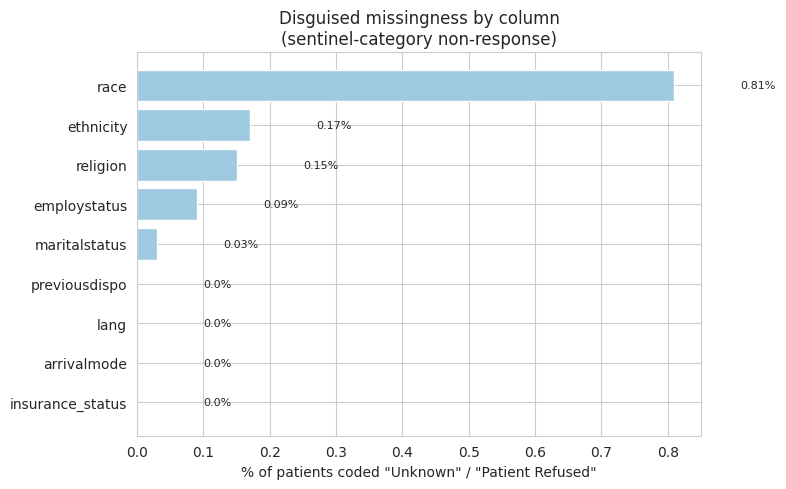

In [20]:
sentinel_labels = {'Unknown', 'Patient Refused'}
categorical_candidates = ['ethnicity', 'race', 'lang', 'religion', 'maritalstatus',
                           'employstatus', 'insurance_status', 'arrivalmode', 'previousdispo']

sentinel_rows = []
for c in categorical_candidates:
    if c not in df.columns:
        continue
    mask = df[c].isin(sentinel_labels)
    sentinel_rows.append({
        'column': c,
        'sentinel_count': int(mask.sum()),
        'sentinel_pct': round(mask.mean() * 100, 2),
        'sentinel_categories_present': sorted(set(df[c].unique()) & sentinel_labels)
    })

sentinel_table = pd.DataFrame(sentinel_rows).sort_values('sentinel_pct', ascending=False).reset_index(drop=True)
display(sentinel_table)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = sentinel_table.sort_values('sentinel_pct', ascending=True)
colors = ['#d62728' if p > 5 else '#ff9896' if p > 1 else '#9ecae1' for p in plot_data['sentinel_pct']]
ax.barh(plot_data['column'], plot_data['sentinel_pct'], color=colors)
ax.set_xlabel('% of patients coded "Unknown" / "Patient Refused"')
ax.set_title('Disguised missingness by column\n(sentinel-category non-response)')
for i, (col, pct) in enumerate(zip(plot_data['column'], plot_data['sentinel_pct'])):
    ax.text(pct + 0.1, i, f'{pct}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Note:** literal NaN missingness is 0% across all 226 columns = this dataset arrived pre-cleaned. Disguised (sentinel-category) missingness is small in absolute terms (well under 1% per field) but concentrated most in `race`, then `ethnicity` and `religion` - worth a subgroup check before the bias/equity audit, since even small non-response can matter if it clusters in one demographic group.

## 6. Missingness visualization (required artefact for `/docs`)

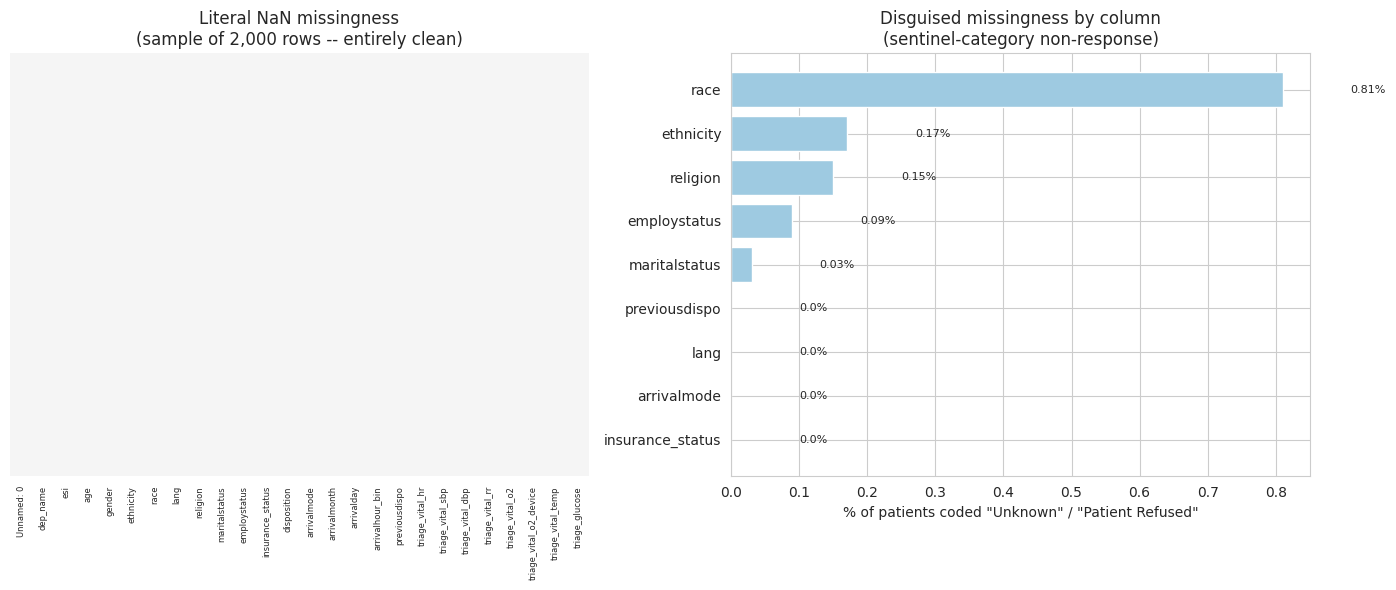

Saved: missingness_visualization.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = df[non_cc_cols].isnull()
sns.heatmap(sample.sample(min(2000, len(sample)), random_state=42), cbar=False,
            cmap=['#f5f5f5'], ax=axes[0])
axes[0].set_title('Literal NaN missingness\n(sample of 2,000 rows -- entirely clean)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, fontsize=6)
axes[0].set_yticks([])

plot_data = sentinel_table.sort_values('sentinel_pct', ascending=True)
colors = ['#d62728' if p > 5 else '#ff9896' if p > 1 else '#9ecae1' for p in plot_data['sentinel_pct']]
axes[1].barh(plot_data['column'], plot_data['sentinel_pct'], color=colors)
axes[1].set_xlabel('% of patients coded "Unknown" / "Patient Refused"')
axes[1].set_title('Disguised missingness by column\n(sentinel-category non-response)')
for i, (col, pct) in enumerate(zip(plot_data['column'], plot_data['sentinel_pct'])):
    axes[1].text(pct + 0.1, i, f'{pct}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('missingness_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: missingness_visualization.png")

from google.colab import files
files.download('missingness_visualization.png')

**Note:** left panel is deliberately blank/clean - that absence of literal NaNs is itself the finding, not a wasted plot. Right panel is the one to lead with in the memo: it shows, at a glance, that `race` has the highest disguised non-response of any demographic field.

## 7. Target variable: ESI (Triage_Level proxy) distribution

,count,pct
esi,,
1.0,77,0.14
2.0,17924,32.52
3.0,27010,49.00
4.0,8896,16.14
5.0,1214,2.20


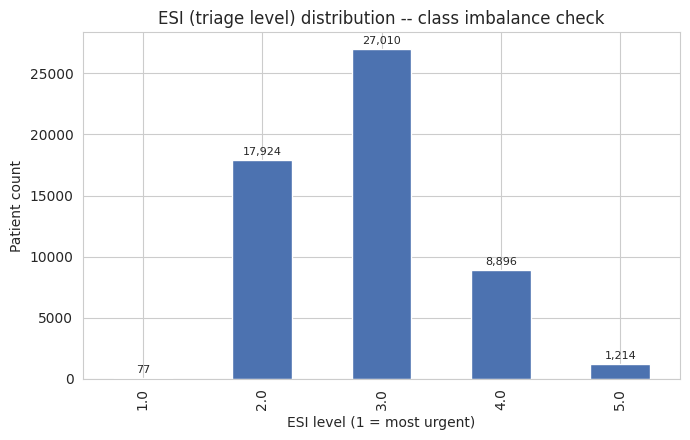

In [19]:
esi_counts = df['esi'].value_counts().sort_index()
esi_pct = (df['esi'].value_counts(normalize=True).sort_index() * 100).round(2)
esi_df = pd.DataFrame({'count': esi_counts, 'pct': esi_pct})
display(esi_df)

fig, ax = plt.subplots(figsize=(7, 4.5))
esi_counts.sort_index().plot(kind='bar', color='#4c72b0', ax=ax)
ax.set_xlabel('ESI level (1 = most urgent)')
ax.set_ylabel('Patient count')
ax.set_title('ESI (triage level) distribution -- class imbalance check')
for i, v in enumerate(esi_counts.sort_index()):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

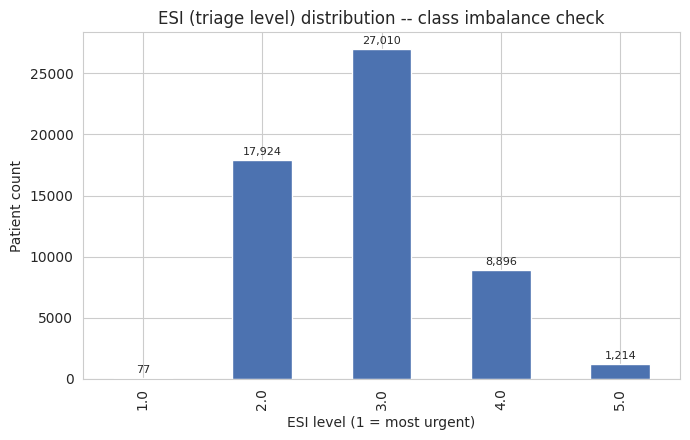

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
esi_counts.sort_index().plot(kind='bar', color='#4c72b0', ax=ax)
ax.set_xlabel('ESI level (1 = most urgent)')
ax.set_ylabel('Patient count')
ax.set_title('ESI (triage level) distribution -- class imbalance check')
for i, v in enumerate(esi_counts.sort_index()):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**Note:** severe class imbalance — ESI 1 (most urgent) is only 0.14% of patients (77 of 55,121), vs. ~49% at ESI 3. Expected clinically (true resuscitations are rare), but Week 6's baseline model needs class weighting or a recall-focused metric, not plain accuracy, or it'll learn to ignore the rare high-stakes cases entirely.

## 8. Chief complaints (`cc_*`)

Number of chief-complaint columns: 200
Average complaints flagged per patient: 1.15
Patients with zero complaints flagged: 0



,0
cc_abdominalpain,6717.0
cc_other,4491.0
cc_chestpain,3712.0
cc_shortnessofbreath,3098.0
cc_backpain,1997.0
cc_fall,1926.0
cc_cough,1439.0
cc_dizziness,1292.0
cc_legpain,1264.0
cc_emesis,1249.0


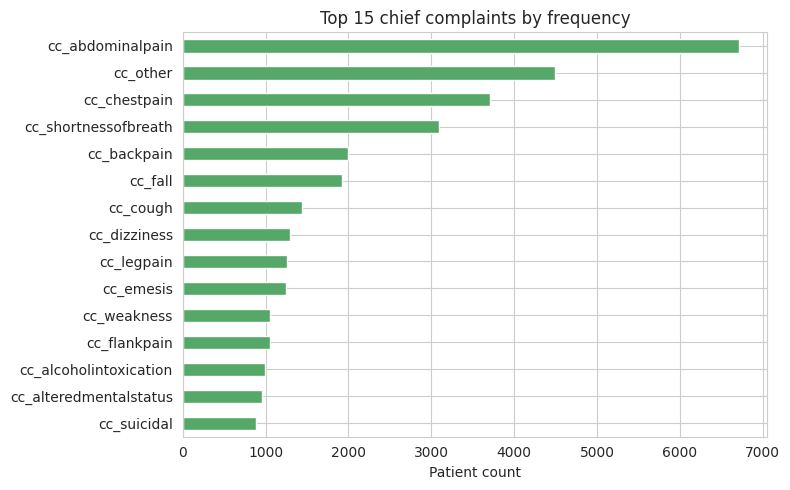

In [18]:
cc_cols = [c for c in df.columns if c.startswith('cc_')]
cc_per_patient = df[cc_cols].sum(axis=1)
print(f"Number of chief-complaint columns: {len(cc_cols)}")
print(f"Average complaints flagged per patient: {cc_per_patient.mean():.2f}")
print(f"Patients with zero complaints flagged: {(cc_per_patient == 0).sum()}")
print()
top15 = df[cc_cols].sum().sort_values(ascending=False).head(15)
display(top15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='#55a868', ax=ax)
ax.set_xlabel('Patient count')
ax.set_title('Top 15 chief complaints by frequency')
plt.tight_layout()
plt.show()

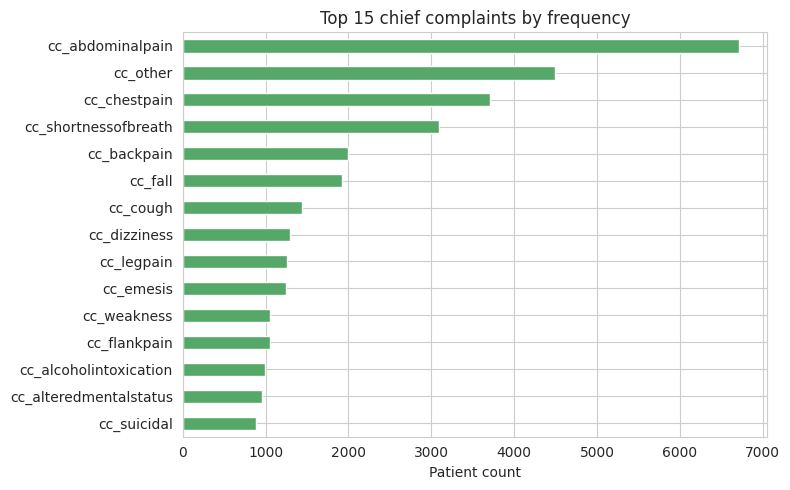

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='#55a868', ax=ax)
ax.set_xlabel('Patient count')
ax.set_title('Top 15 chief complaints by frequency')
plt.tight_layout()
plt.show()

**Note:** abdominal pain, chest pain, and shortness of breath top the list - clinically plausible for a general ED population, and a reasonable starting point for the Week 5 feature shortlist given their volume.

## 9. Vitals vs. ESI - plausibility check

,triage_vital_hr,triage_vital_rr,triage_vital_o2,age
esi,,,,
1.0,89.96,19.73,95.81,68.88
2.0,88.67,18.08,96.51,60.67
3.0,85.79,17.79,97.18,54.76
4.0,84.40,17.58,97.51,47.43
5.0,83.07,17.30,97.67,45.69


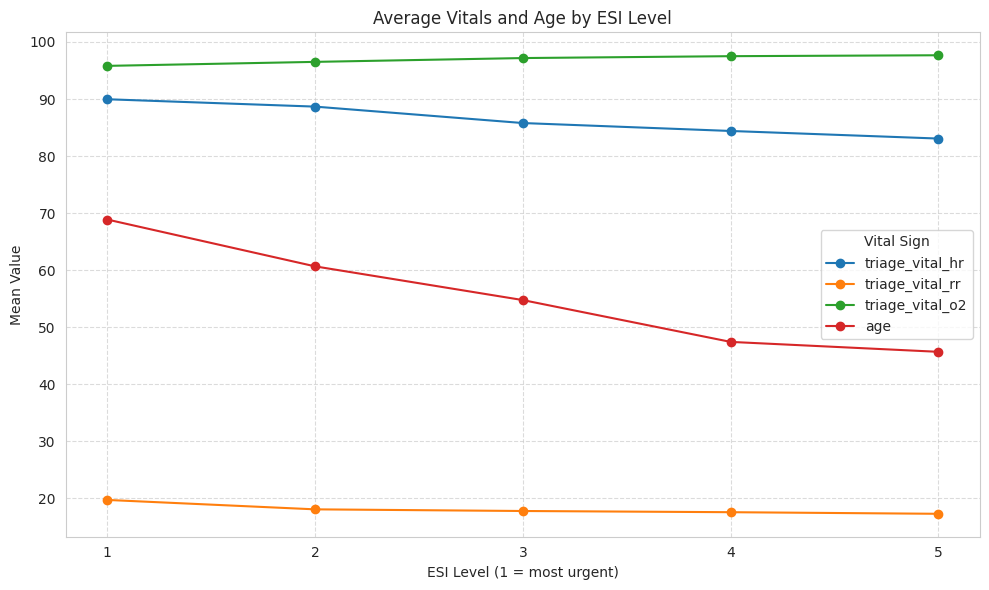

In [17]:
esi_vitals = df.groupby('esi')[['triage_vital_hr', 'triage_vital_rr', 'triage_vital_o2', 'age']].mean().round(2)
display(esi_vitals)

fig, ax = plt.subplots(figsize=(10, 6))
esi_vitals.plot(kind='line', marker='o', ax=ax)
ax.set_title('Average Vitals and Age by ESI Level')
ax.set_xlabel('ESI Level (1 = most urgent)')
ax.set_ylabel('Mean Value')
ax.set_xticks(esi_vitals.index)
ax.legend(title='Vital Sign')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Note:** heart rate and respiratory rate trend up, and O2 sat trends down, as ESI moves toward 1 (more urgent) - vitals move in the clinically expected direction relative to acuity. This is a positive feasibility signal: the labels look internally consistent with the physiology, not arbitrary.